In [1]:
import numpy as np
import pennylane as qp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## Circuit
Variational circuit targeting the Bell state |Φ+> = (|00> + |11>)/√2.
The single trainable parameter p controls the RY rotation on qubit 0.

(<Figure size 500x300 with 1 Axes>, <Axes: >)

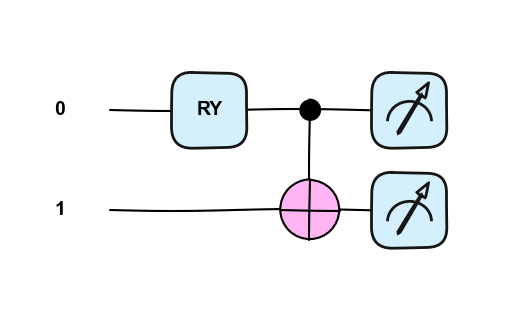

In [2]:
# The target states are |00> and |11>

dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def circuit(p):
    
    ## creates a Bell state phi+: RY with a parameter p rotates qubit 0 into superposition, CNOT entangles the two qubits
    qp.RY(p, wires=[0])
    qp.CNOT([0,1])

    # first expval to see if we get 0 50% of the time and 1 50% of the time for the first qubit
    # second expval to see if there's a correlation between the two qubits
    return qp.expval(qp.Z(0)), qp.expval(qp.Z(0)@qp.Z(1)) 
# circuit visualization
qp.draw_mpl(circuit, style="pennylane_sketch")(0)

## Optimization 
Classical gradient methods require accessing the circuit's internal state directly,
which isn't possible on real hardware without collapsing the quantum state.
The parameter-shift rule works around this by only requiring circuit evaluations at shifted parameters (p ± π/2)

In [3]:
def grad(circ, p):
    """Computes gradient at p using the parameter-shift rule"""
    de_0 = (circ(p+np.pi/2)[0] - circ(p-np.pi/2)[0])/2
    de_01 = (circ(p+np.pi/2)[1] - circ(p-np.pi/2)[1])/2
    e_0 = circ(p)[0]
    e_01 = circ(p)[1]

    return 2*(e_0*de_0 + (e_01-1)*de_01)

# gradient descent optimizer & returns parameter history
def param_update(circ, p, lr=0.002, epsilon=0.0001, max_iter=1000):
    """
    simple gradient descent optimizer 
    
    circ     : circuit to optimize
    p        : initial parameter value
    lr       : learning rate (default 0.002)
    epsilon  : convergence threshold (default 0.0001)
    max_iter : max iterations (default 1000)
    """
    
    iteration = 0
    params = [p]
    
    while iteration<max_iter :
        p_old = p
        
        p -= lr*grad(circ,p)
        params.append(p)

        if abs(p-p_old)<=epsilon:
            print(f"Converged at iteration {iteration+1}, parameter={p:.4f}, error: {abs(p-p_old):.4f}")
            break
        
        if (iteration+1)%50==0:
            print(f"Iteration: {iteration+1}, parameter={p:.4f}")
            
        iteration += 1

    return params

In [4]:
# run optimization starting from p=3.0
params = param_update(circuit,3.0,max_iter=2000)

Iteration: 50, parameter=2.9693
Iteration: 100, parameter=2.9322
Iteration: 150, parameter=2.8877
Iteration: 200, parameter=2.8348
Iteration: 250, parameter=2.7725
Iteration: 300, parameter=2.7003
Iteration: 350, parameter=2.6184
Iteration: 400, parameter=2.5280
Iteration: 450, parameter=2.4312
Iteration: 500, parameter=2.3315
Iteration: 550, parameter=2.2328
Iteration: 600, parameter=2.1386
Iteration: 650, parameter=2.0520
Iteration: 700, parameter=1.9747
Iteration: 750, parameter=1.9073
Iteration: 800, parameter=1.8497
Iteration: 850, parameter=1.8010
Iteration: 900, parameter=1.7603
Iteration: 950, parameter=1.7265
Iteration: 1000, parameter=1.6986
Iteration: 1050, parameter=1.6755
Iteration: 1100, parameter=1.6566
Iteration: 1150, parameter=1.6411
Iteration: 1200, parameter=1.6284
Iteration: 1250, parameter=1.6179
Iteration: 1300, parameter=1.6094
Iteration: 1350, parameter=1.6024
Iteration: 1400, parameter=1.5966
Converged at iteration 1410, parameter=1.5956, error: 0.0001


## Results
At the optimal parameter, the circuit should produce |00> and |11> with equal probability (~0.5),
confirming the Bell state was reached.

In [5]:
# separate qnode just for visualization — returns probabilities of each basis state
@qp.qnode(dev)
def circuit_probs(p):
    qp.RY(p, wires=[0])
    qp.CNOT([0, 1])
    return qp.probs()

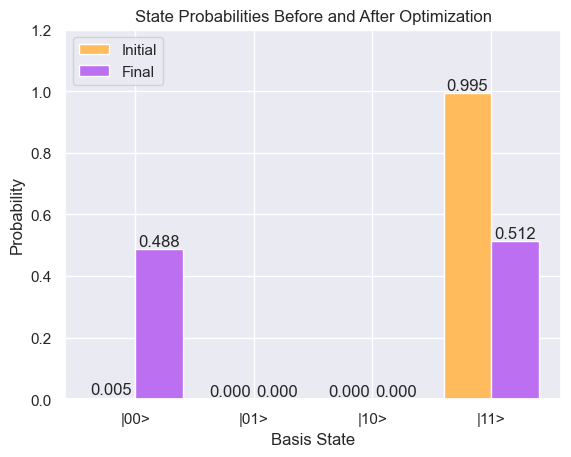

In [6]:
# compare initial state |00> vs final state after optimization
labels = ['|00>', '|01>', '|10>', '|11>']
initial_probs = circuit_probs(params[0])
final_probs = circuit_probs(params[-1])

x = np.arange(4)

b1 = plt.bar(x - 0.2, initial_probs, 0.4, label='Initial', color='#FFBB5C')
b2 = plt.bar(x + 0.2, final_probs, 0.4, label='Final', color='#BC6FF1')

plt.bar_label(b1, fmt='%.3f') 
plt.bar_label(b2, fmt='%.3f')
plt.xticks(x, labels)
plt.legend()
plt.ylim(0, 1.2)
plt.xlabel('Basis State')
plt.ylabel('Probability')
plt.title('State Probabilities Before and After Optimization')
plt.savefig('figures/state-probabilities.png', dpi=300, bbox_inches='tight')
plt.show()

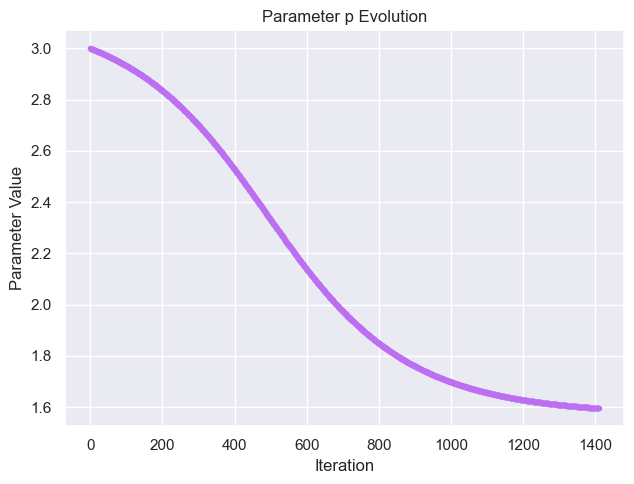

In [7]:
# parameter value across iterations
plt.figure(figsize=(6.5,5))
plt.plot(params, marker='.', color='#BC6FF1')
plt.xlabel('Iteration')
plt.ylabel('Parameter Value')
plt.title('Parameter p Evolution')
plt.tight_layout()
plt.show()